# Analyse an Elmer/Ice run against observations

Compares one model member (a single XIOS run, or one SmallEnsTrans member)
against satellite observations: grounding-line discharge and mass balance by
Mouginot catchment (§1a), then 2D velocity / dH/dt maps (§1b).

Shared setup — mesh geometry, flux integrators, per-member diagnostics — lives in
`elmer_analysis.py`. **Ensemble analysis is in `AnalyseEnsemble.ipynb`.**

## §0 — Configuration & setup

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import xugrid as xu
import matplotlib.pyplot as plt
import proplot as pplt              # figure styling used by the line plots
import itertools
from itertools import combinations as iter_combinations
from pathlib import Path
# Requires in the env: xugrid, xarray, proplot, cftime (for 360_day obs calendars).

/home/jagereli/.conda/envs/mahti_env/lib/python3.9/site-packages/proplot/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [3]:
import elmer_analysis as ea

# ── EDIT ME: point this at YOUR run ─────────────────────────────────────────
CONFIG = ea.Config(
    # ElmerUgrid checkout (see README) -- registers .ugrid.to_netcdf_forpv
    postpro_dir      = "/home/jagereli/Postdoc/Data/postpro/elmerugrid",

    # Your XIOS output: states = geometry/velocity/groundedmask/haf/cell_area,
    # forcing = smb_total_flux (face) / bmb (node) / ligroundf.
    member_kind      = "ocx",
    ocx_states_file  = "/media/jagereli/Expansion1/TLC_ISMIP7_ANT/SSA_POC/AA_SSA_ISMIP7_OCX_MAHTI/ssp126_c005_states.nc",
    ocx_forcing_file = "/media/jagereli/Expansion1/TLC_ISMIP7_ANT/SSA_POC/AA_SSA_ISMIP7_OCX_MAHTI/ssp126_c005_forcing.nc",

    # Mesh-specific products for THAT mesh, from preprocessing/build_mesh_products.py
    basins_file      = "../DATA/basins_mouginotGrid_ocx.nc",
    obs_mesh_file    = "../DATA/obs_on_elmer_mesh_pv_ocx.nc",

    # Raw observations (see README for download links)
    obs_ismip_file     = "../DATA/AntarcticaObsISMIP7-v1.2.nc",
    obs_discharge_file = "../DATA/AIS_discharge_BMHF14.nc",
)

# Loads the mesh, basins and observations, and brings the shared names
# (times, basins, basin_ids, face_areas, node_to_face, savefig, ...) into scope.
globals().update(ea.init(CONFIG))

Mesh (ocx): 929491 nodes, 1825205 faces
Mesh reference file: /media/jagereli/Expansion1/TLC_ISMIP7_ANT/SSA_POC/AA_SSA_ISMIP7_OCX_MAHTI/ssp126_c005_states.nc
n_time=35, years 1991.0-2025.0
cell_area (real, from XIOS): total 1.357e+13 m2
face_areas: min=3.605e+02, max=1.826e+09 m2, total=1.357e+13 m2 (expect ~1.4e13)
edge_len: min=4.0, max=71131.3 m


## §1 — Single / averaged member vs observations

### 1a — Global: discharge & mass change by catchment

In [4]:
# The member to analyse. `member_diag_dataset()` runs the full per-catchment mass
# budget (SMB, BMB, calving, GL discharge) for it -- takes a few minutes.
member = member_diag_dataset()
MEMBER_PATH = CONFIG.ocx_states_file if CONFIG.member_kind == "ocx" else member_files[0]
print("Analysing:", member.attrs["label"])
member

Analysing: OCX C011


<xarray.Dataset>
Dimensions:        (time: 35, catchment: 18)
Coordinates:
  * time           (time) float64 1.991e+03 1.992e+03 ... 2.024e+03 2.025e+03
  * catchment      (catchment) int64 1 2 3 4 5 6 7 8 ... 11 12 13 14 15 16 17 18
Data variables: (12/14)
    iaf_mass       (time, catchment) float64 1.125e+06 9.56e+05 ... 2.587e+05
    grounded_mass  (time, catchment) float64 1.173e+06 9.701e+05 ... 2.99e+05
    shelf_mass     (time, catchment) float64 3.583e+04 3.633e+03 ... 2.242e+04
    grounded_area  (time, catchment) float64 7.724e+05 6.48e+05 ... 2.582e+05
    floating_area  (time, catchment) float64 1.245e+05 1.394e+04 ... 9.205e+04
    smb_grounded   (time, catchment) float64 96.85 150.5 98.68 ... 147.4 58.89
    ...             ...
    bmb_floating   (time, catchment) float64 -41.59 -6.457 ... -53.24 -38.43
    calving_face   (time, catchment) float64 47.89 52.24 3.871 ... 78.79 42.14
    calving_edge   (time, catchment) float64 51.11 54.19 4.365 ... 80.01 52.82
    gl_discharge   (time, catchment) float64 103.5 76.92 99.3 ... 86.83 45.51
    smb            (time, catchment) float64 132.5 158.9 106.6 ... 167.2 91.22
    mass_balance   (time, catchment) float64 -6.679 73.58 ... 60.59 13.38
Attributes:
    label:    OCX C011

In [5]:
# Observed grounding-line discharge (BMHF14 / IMBIE), or None if the file is absent.
obs_disch = load_obs_discharge()

/home/jagereli/.conda/envs/mahti_env/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 8315 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/home/jagereli/.conda/envs/mahti_env/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:203: RuntimeWarning: Glyph 8315 missing from current font.
  font.set_text(s, 0, flags=flags)


Saved figures/1a_gl_discharge_by_catchment_OCX_C011.png


(Figure(nrows=3, ncols=6, figwidth=18.0, figheight=9.0),
 SubplotGrid(nrows=3, ncols=6, length=18))

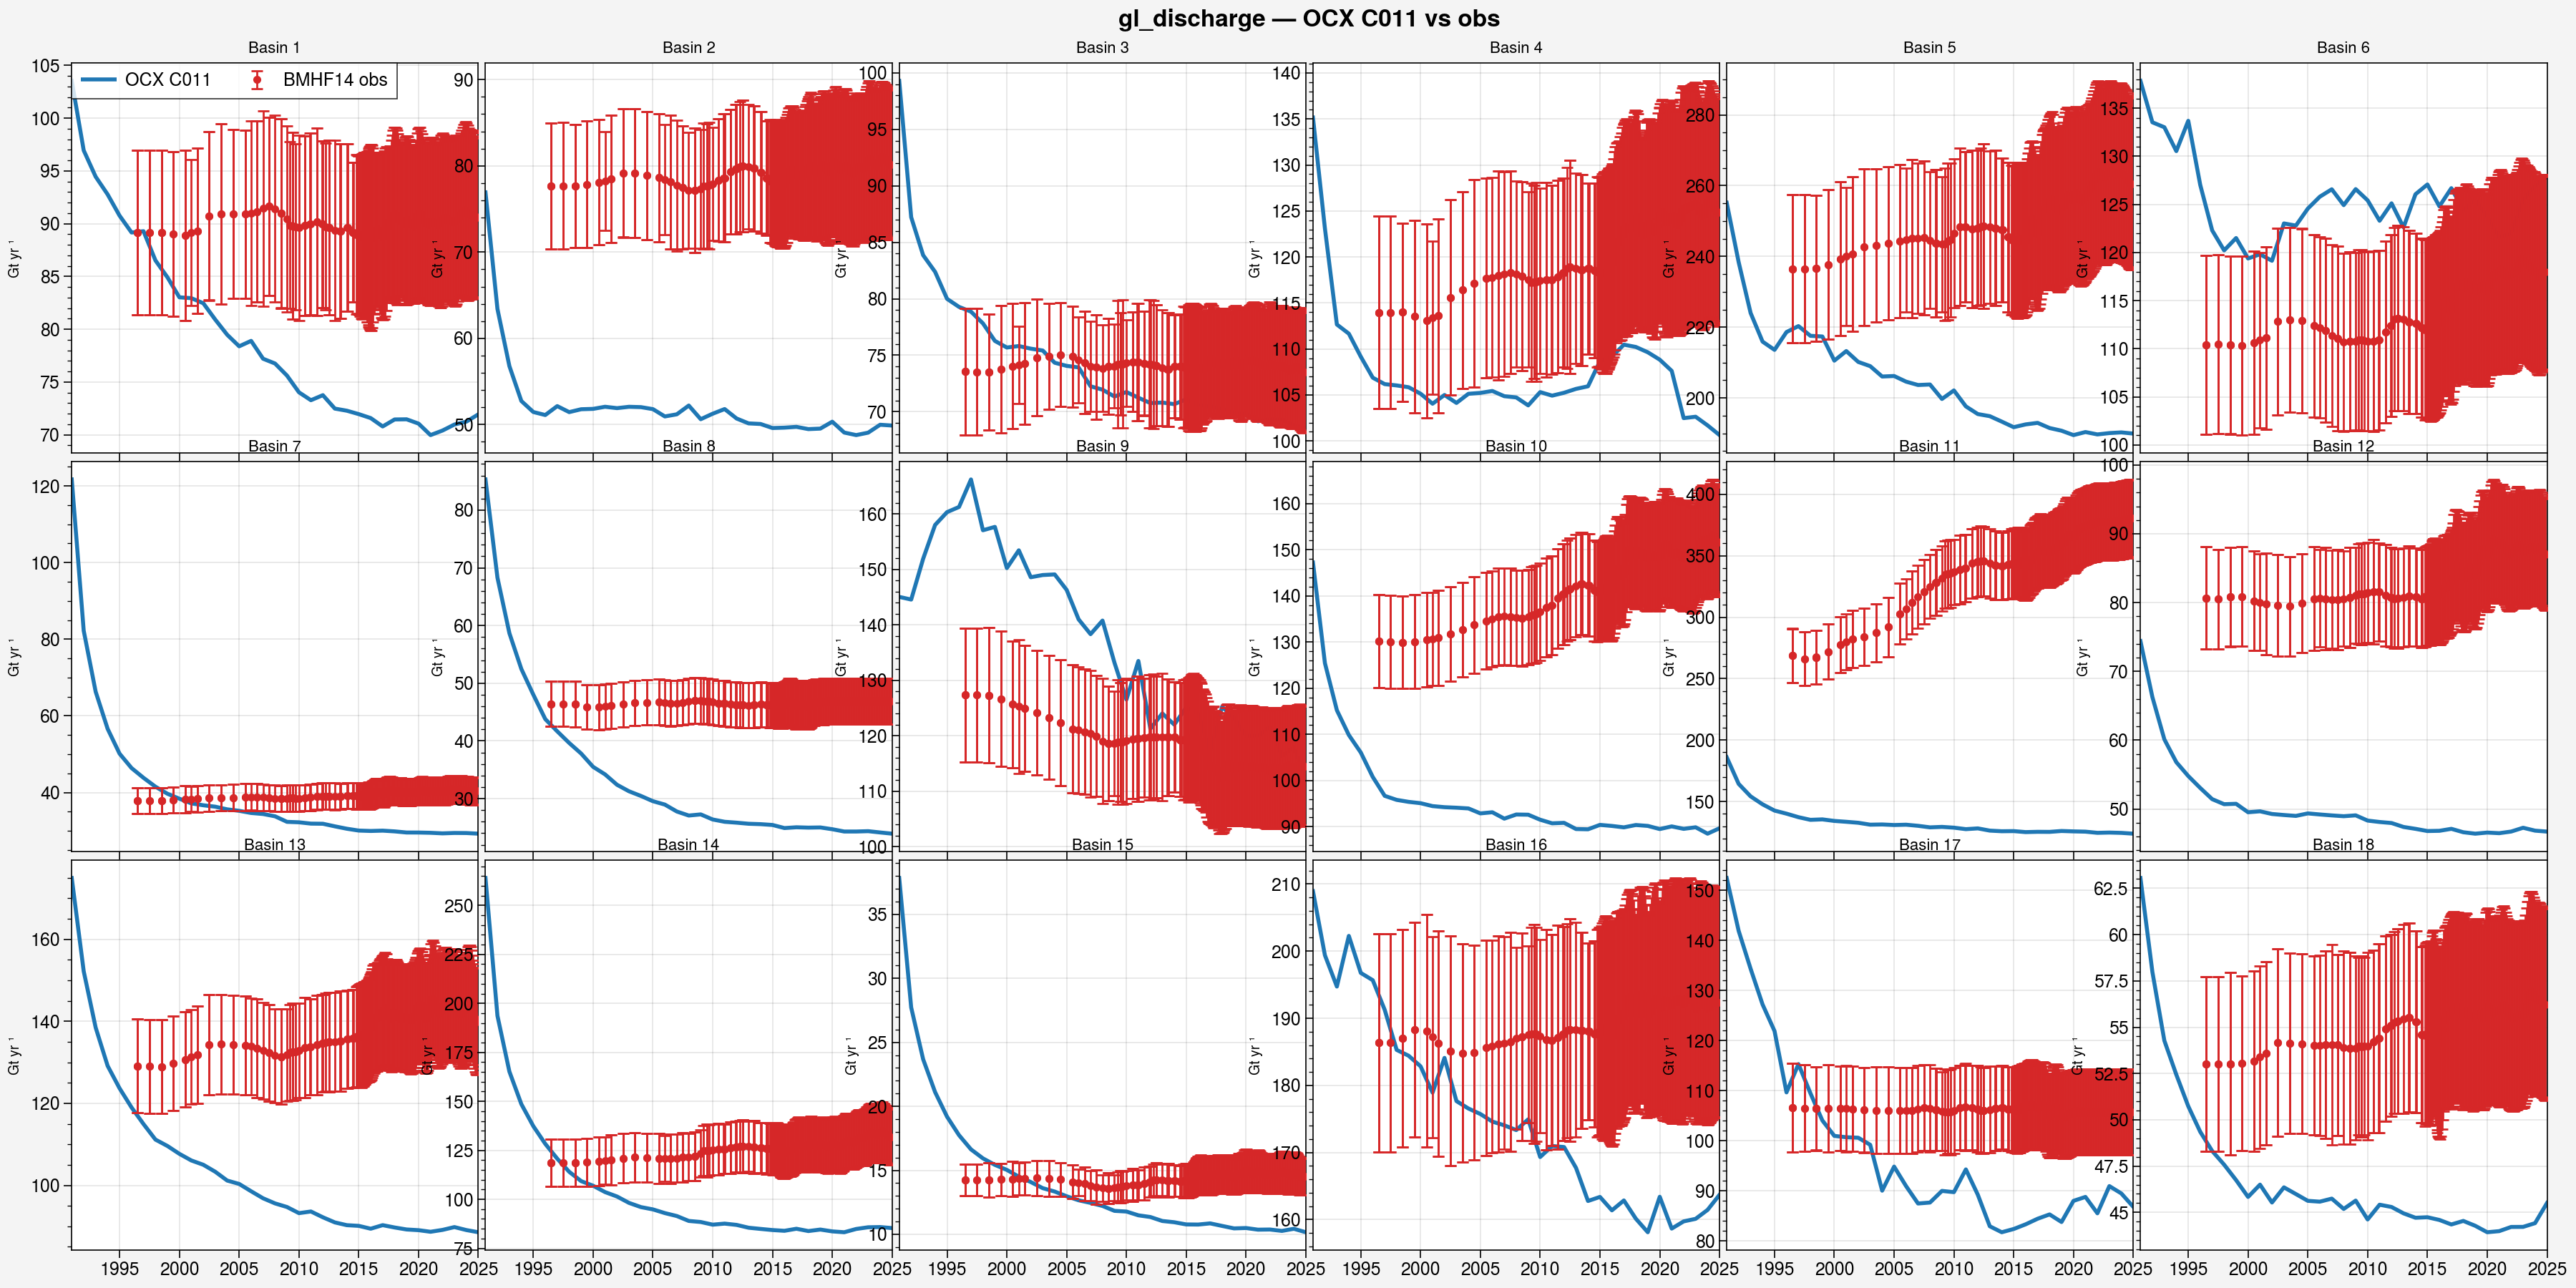

In [6]:
def plot_member_by_catchment(member, variable="gl_discharge",
                             obs=obs_disch, overlay_obs=True):
    """3x6 grid, one Mouginot catchment per panel: model line (+ obs discharge)."""
    cids = [c for c in member["catchment"].values if 1 <= int(c) <= 18]
    fig, axes = pplt.subplots(nrows=3, ncols=6, figsize=(18, 9),
                              sharey=False, sharex=True, hspace=0.5, wspace=0.4)
    for ax, cid in zip(axes, cids):
        y = member[variable].sel(catchment=cid).values
        ax.plot(years, y, color="tab:blue", lw=2, label=member.attrs["label"])
        if overlay_obs and obs is not None and variable == "gl_discharge":
            oyears, d, de = obs
            ib = int(cid) - 1
            v = ~np.isnan(d[:, ib])
            ax.errorbar(oyears[v], d[v, ib], yerr=de[v, ib], fmt="o",
                        color="tab:red", ms=3, lw=1, label="BMHF14 obs", zorder=5)
        ax.set_title(f"Basin {int(cid)}", fontsize=8)
        ax.set_ylabel("Gt yr⁻¹", fontsize=7); ax.format(xminorlocator=5)
    axes[0].legend(fontsize=7, loc="upper left")
    fig.suptitle(f"{variable} — {member.attrs['label']} vs obs", fontsize=12)
    savefig(fig, f"1a_{variable}_by_catchment_{slug(member.attrs['label'])}")
    return fig, axes

plot_member_by_catchment(member, "gl_discharge")

/home/jagereli/.conda/envs/mahti_env/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 8315 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/home/jagereli/.conda/envs/mahti_env/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:203: RuntimeWarning: Glyph 8315 missing from current font.
  font.set_text(s, 0, flags=flags)


Saved figures/1a_gl_discharge_ligroundf_crosscheck_OCX_C011.png


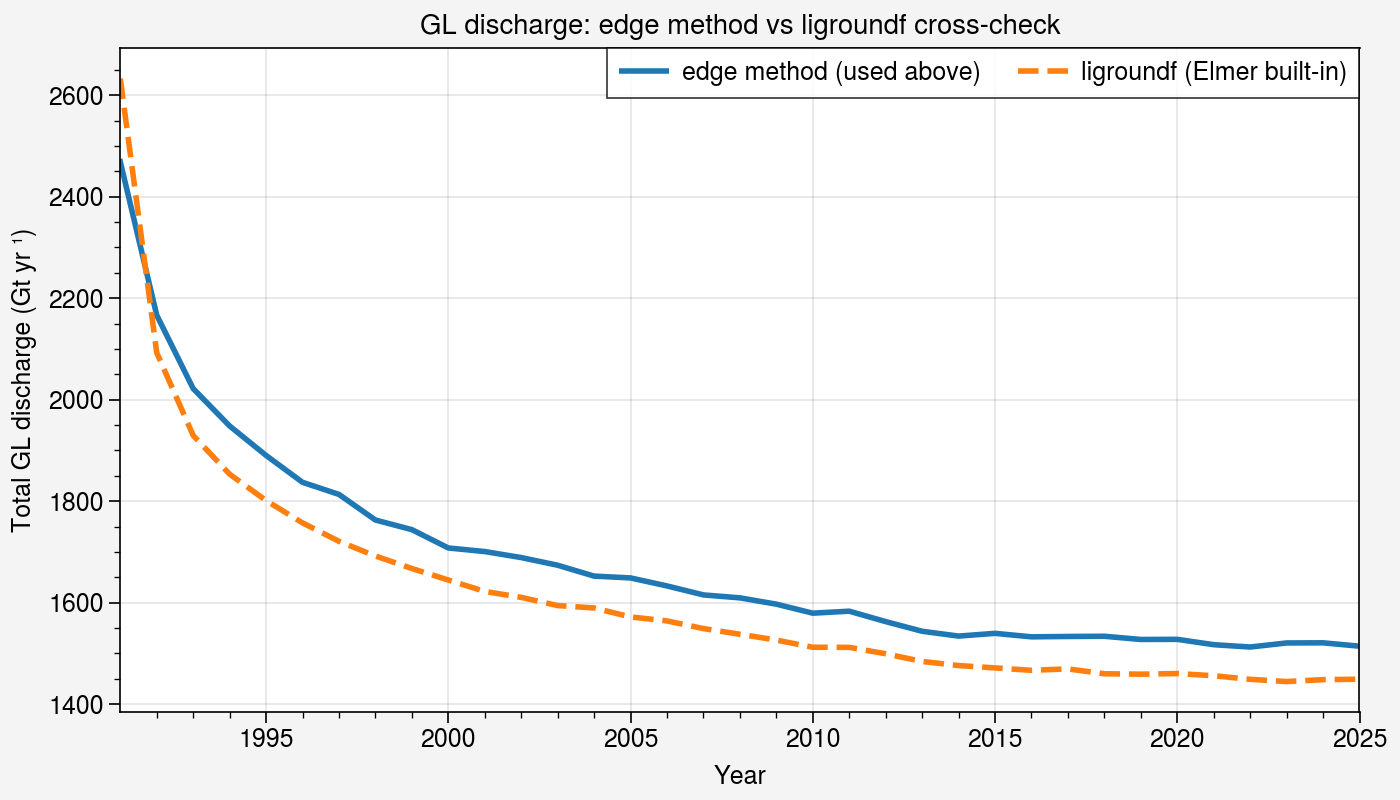

In [7]:
if CONFIG.member_kind == "ocx":
    uds_f = xu.open_dataset(str(CONFIG.ocx_forcing_file), mask_and_scale=True, decode_times=False)
    ligroundf = uds_f["ligroundf"].values          # (time, n_faces), m ice a-1
    uds_f.close()
    gl_ligroundf_total = np.nansum(np.where(ligroundf > 0, ligroundf, 0.0) *
                                   face_areas[None, :], axis=1) * RHO_ICE * GT
    gl_edge_total = member["gl_discharge"].sum("catchment").values
    fig, ax = pplt.subplots(figsize=(7, 4))
    ax.plot(years, gl_edge_total,      color="tab:blue", lw=2, label="edge method (used above)")
    ax.plot(years, gl_ligroundf_total, color="tab:orange", lw=2, ls="--", label="ligroundf (Elmer built-in)")
    ax.set_xlabel("Year"); ax.set_ylabel("Total GL discharge (Gt yr⁻¹)")
    ax.legend(loc="best", fontsize=8)
    ax.format(title="GL discharge: edge method vs ligroundf cross-check")
    savefig(fig, f"1a_gl_discharge_ligroundf_crosscheck_{slug(member.attrs['label'])}")
else:
    print("SmallEnsTrans has no ligroundf field -> cross-check skipped.")

Saved figures/1a_cumulative_mb_by_catchment_OCX_C011.png


(Figure(nrows=3, ncols=6, figwidth=18.0, figheight=9.0),
 SubplotGrid(nrows=3, ncols=6, length=18))

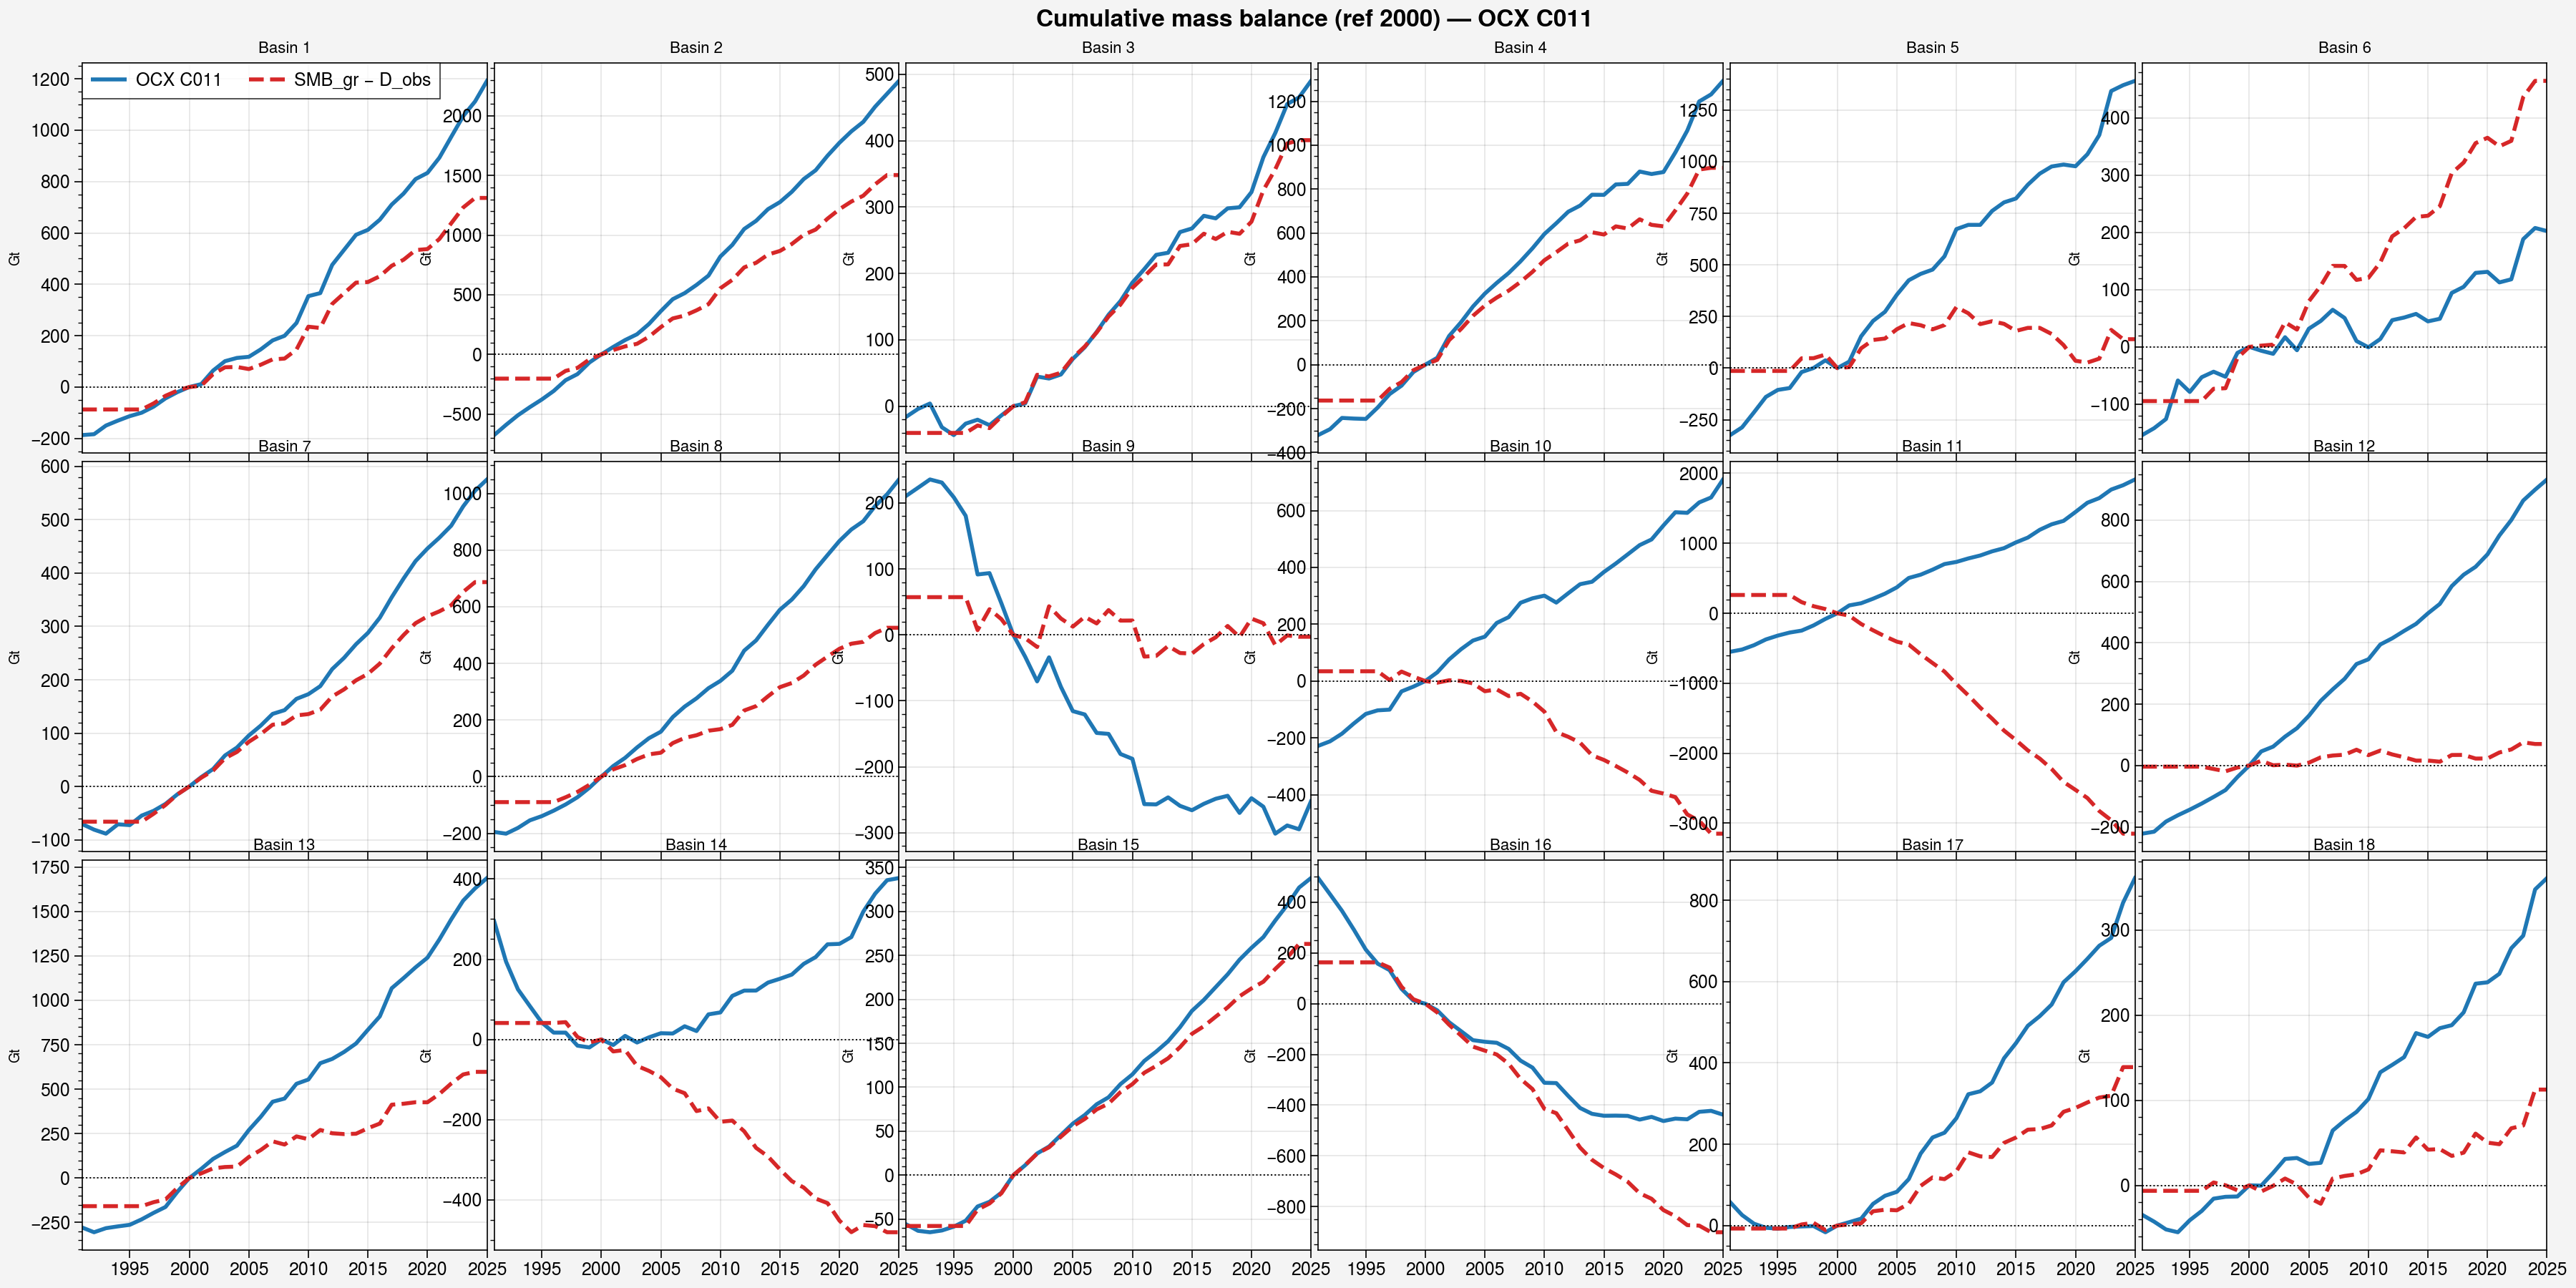

In [8]:
# ── Cumulative mass change by catchment (grounded MB = SMB_gr - D), ref 2000 ──
def plot_member_cumulative_mb(member, obs=obs_disch, ref_year=2000):
    cids = [c for c in member["catchment"].values if 1 <= int(c) <= 18]
    ref  = int(np.argmin(np.abs(years - ref_year)))
    fig, axes = pplt.subplots(nrows=3, ncols=6, figsize=(18, 9),
                              sharey=False, sharex=True, hspace=0.5, wspace=0.4)
    for ax, cid in zip(axes, cids):
        mb = member["mass_balance"].sel(catchment=cid).values
        cum = np.nancumsum(mb); cum -= cum[ref]
        ax.plot(years, cum, color="tab:blue", lw=2, label=member.attrs["label"])
        if obs is not None:
            oyears, d, de = obs
            ib = int(cid) - 1; v = ~np.isnan(d[:, ib])
            if v.sum() >= 2:
                d_i = np.interp(years, oyears[v], d[v, ib], left=np.nan, right=np.nan)
                smb = member["smb_grounded"].sel(catchment=cid).values
                cum_o = np.nancumsum(smb - d_i); cum_o -= cum_o[ref]
                ax.plot(years, cum_o, color="tab:red", lw=2, ls="--",
                        label="SMB_gr − D_obs")
        ax.axhline(0, color="k", lw=0.7, ls=":")
        ax.set_title(f"Basin {int(cid)}", fontsize=8)
        ax.set_ylabel("Gt", fontsize=7); ax.format(xminorlocator=5)
    axes[0].legend(fontsize=7, loc="upper left")
    fig.suptitle(f"Cumulative mass balance (ref {ref_year}) — "
                 f"{member.attrs['label']}", fontsize=12)
    savefig(fig, f"1a_cumulative_mb_by_catchment_{slug(member.attrs['label'])}")
    return fig, axes

plot_member_cumulative_mb(member)

### 1b — 2D maps: velocity & dH/dt vs obs

(<Figure size 1500x500 with 5 Axes>,
 array([<AxesSubplot:title={'center':'model 2005'}, xlabel='x', ylabel='y'>,
        <AxesSubplot:title={'center':'obs 2005.5'}, xlabel='x', ylabel='y'>,
        <AxesSubplot:title={'center':'model − obs'}, xlabel='x', ylabel='y'>],
       dtype=object))

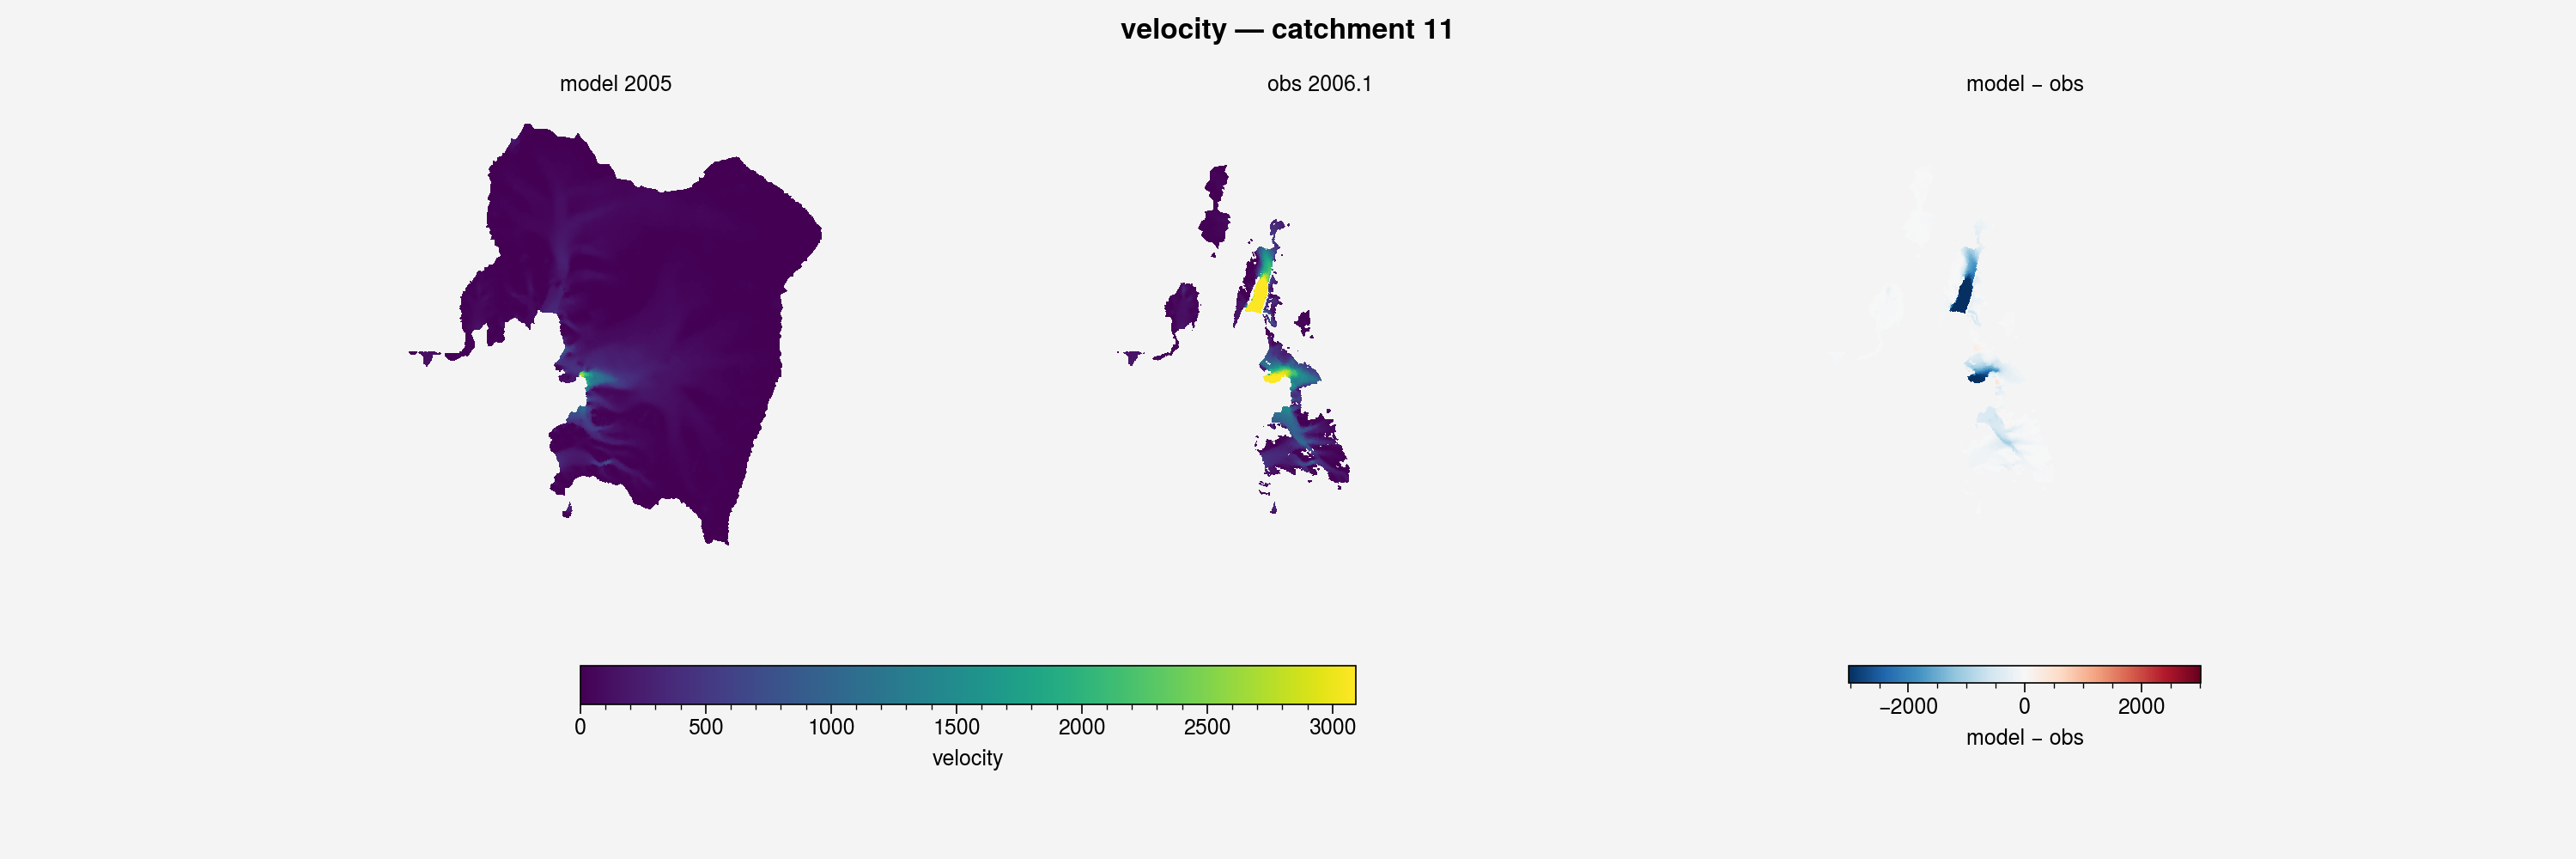

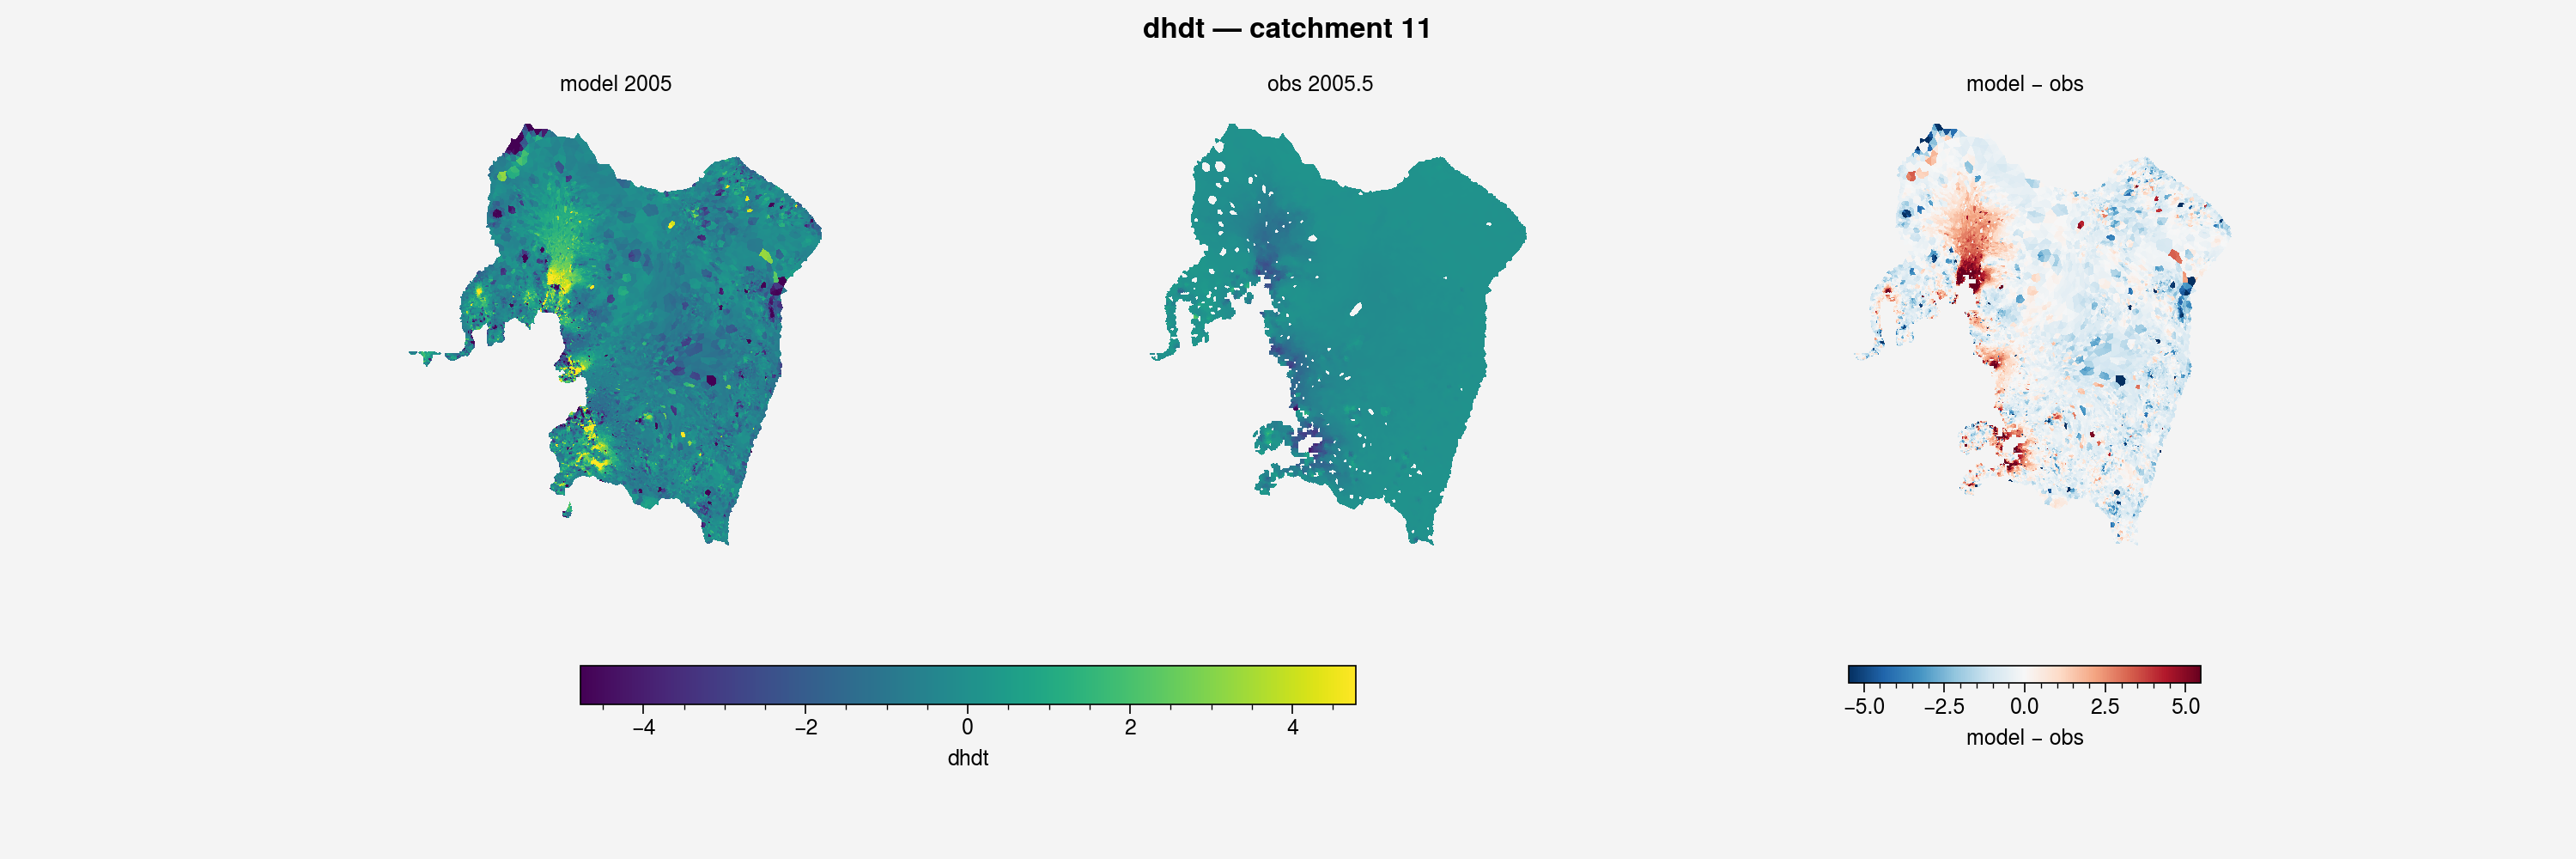

In [9]:
# ── Single-member 3-panel map: model | obs | (model − obs) ───────────────────
def plot_member_vs_obs_2d(fpath, catchment, year, variable="velocity", kind=CONFIG.member_kind,
                          cmap_abs="viridis", cmap_diff="RdBu_r",
                          vmax_abs=None, vmax_diff=None):
    xlim, ylim = get_catchment_bounds(catchment)
    t_idx = int(np.argmin(np.abs(times - year)))
    mod_da = load_model_snapshot_ugrid(fpath, variable, t_idx, kind=kind)
    if variable == "velocity":
        obs_da, obs_date = get_obs_velocity_at_year(year)
    else:
        obs_da, obs_date = get_obs_dhdt_at_year(year)
    diff_da = mod_da - obs_da

    m = get_catchment_mask(catchment)
    if vmax_abs is None:
        a = np.concatenate([mod_da.values[m], obs_da.values[m]])
        vmax_abs = np.nanpercentile(a[np.isfinite(a)], 98)
    if vmax_diff is None:
        d = diff_da.values[m]
        vmax_diff = np.nanpercentile(np.abs(d[np.isfinite(d)]), 95)
    vmin_abs = 0.0 if variable == "velocity" else -vmax_abs

    fig, axes = plt.subplots(ncols=3, figsize=(15, 5))
    p0 = plot_catchment_field(axes[0], mod_da,  catchment, xlim, ylim, cmap_abs, vmin_abs, vmax_abs)
    p1 = plot_catchment_field(axes[1], obs_da,  catchment, xlim, ylim, cmap_abs, vmin_abs, vmax_abs)
    p2 = plot_catchment_field(axes[2], diff_da, catchment, xlim, ylim, cmap_diff, -vmax_diff, vmax_diff)
    axes[0].set_title(f"model {int(times[t_idx])}", fontsize=9)
    axes[1].set_title(f"obs {obs_date}", fontsize=9)
    axes[2].set_title("model − obs", fontsize=9)
    fig.colorbar(p1, ax=[axes[0], axes[1]], location="bottom", shrink=0.6, label=variable)
    fig.colorbar(p2, ax=axes[2], location="bottom", shrink=0.6, label="model − obs")
    fig.suptitle(f"{variable} — catchment {catchment}", fontsize=12)
    return fig, axes

plot_member_vs_obs_2d(MEMBER_PATH, catchment=11, year=2005, variable="velocity")
plot_member_vs_obs_2d(MEMBER_PATH, catchment=11, year=2005, variable="dhdt")

(<Figure size 1600x1200 with 14 Axes>,
 array([[<AxesSubplot:title={'center':'model 1995\nmean=185'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'model 2005\nmean=168'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'model 2015\nmean=159'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'model 2025\nmean=153'}, xlabel='x', ylabel='y'>],
        [<AxesSubplot:title={'center':'obs 2001.1\nmean=812'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'obs 2006.1\nmean=795'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'obs 2015.1\nmean=527'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'obs 2020.1\nmean=557'}, xlabel='x', ylabel='y'>],
        [<AxesSubplot:title={'center':'model − obs'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'model − obs'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'model − obs'}, xlabel='x', ylabel='y'>,
         <AxesSubp

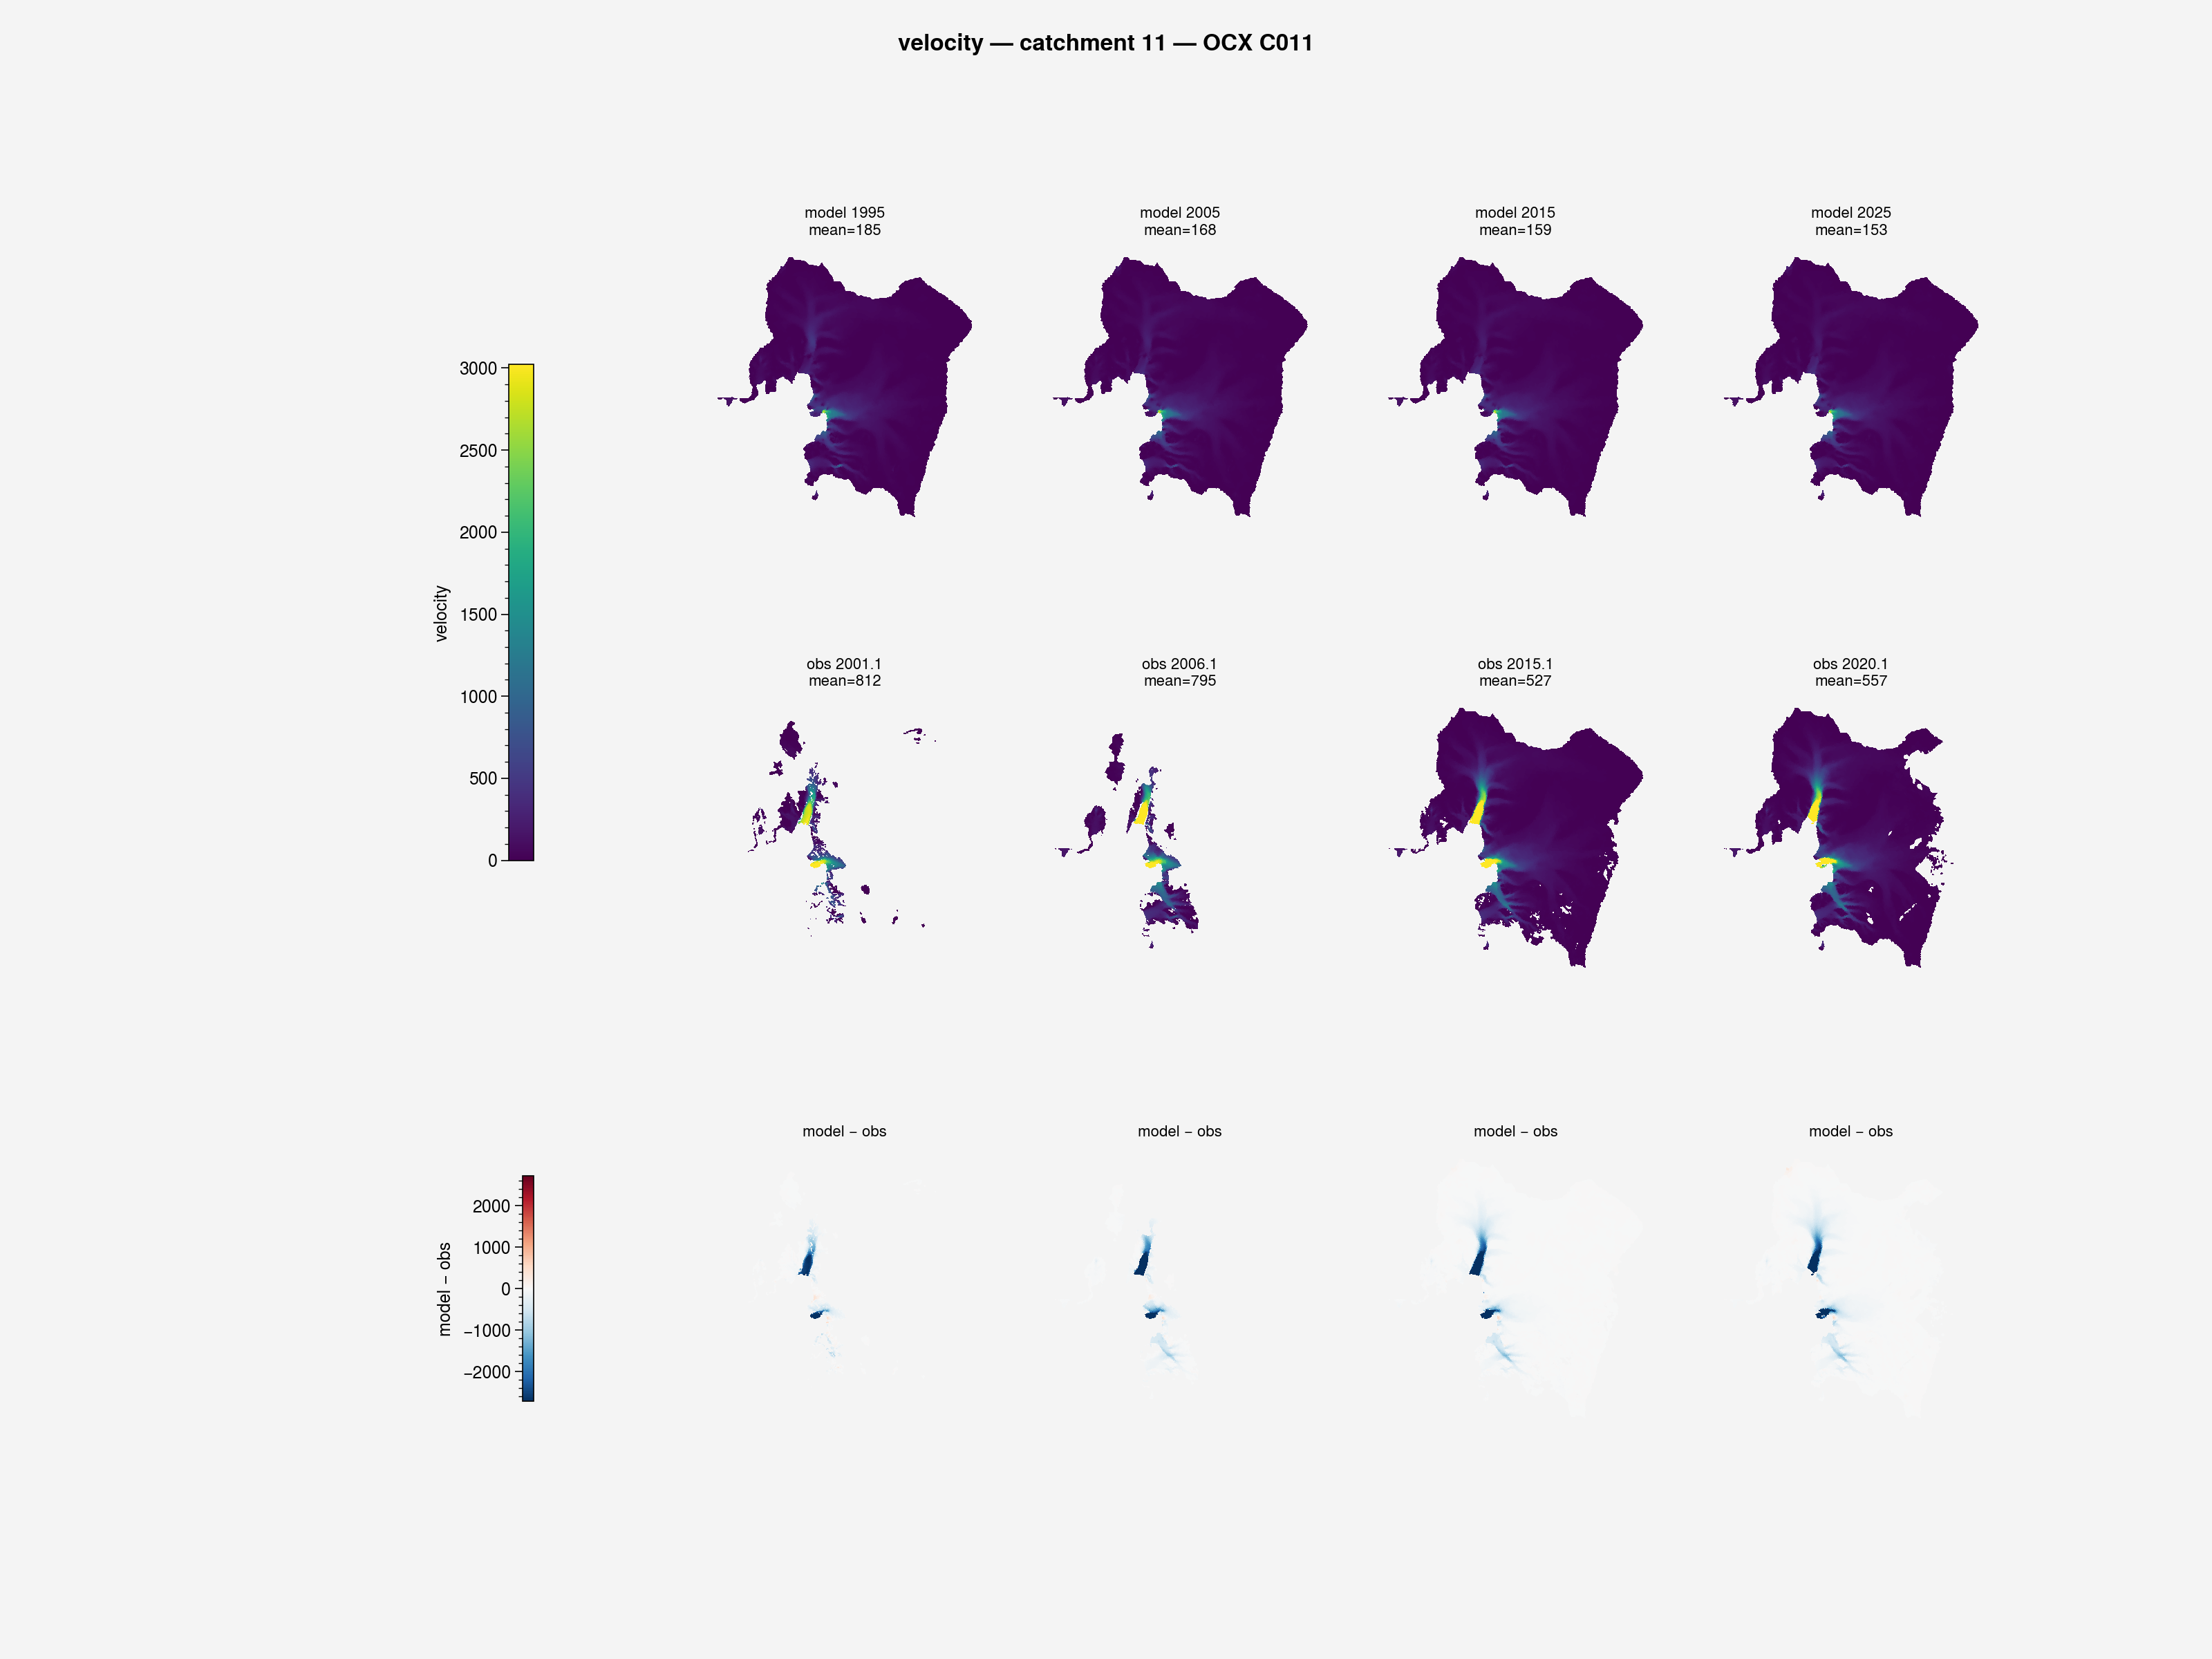

In [10]:
def plot_temporal_maps(
    catchment: int, fpath, kind: str = CONFIG.member_kind, variable: str = "velocity",
    years_to_plot: list = (2001, 2005, 2010, 2014), show_obs: bool = True,
    cmap_abs: str = "viridis", cmap_diff: str = "RdBu_r",
    vmin_abs: float = None, vmax_abs: float = None, vmax_diff: float = None,
):
    """Rows: model | obs | (model-obs); one column per year.

    Titles include each panel's catchment-mean value. The colour scale is
    shared across columns (needed for a fair year-to-year comparison), which
    means real but modest changes -- a few percent over a decade is typical
    for most catchments -- can be hard to see by eye, especially where a
    fast-flowing core saturates the colormap. The mean annotation makes the
    real (if visually subtle) change legible even when the maps look similar.
    """
    xlim, ylim = get_catchment_bounds(catchment)
    catch_mask = get_catchment_mask(catchment)
    n_years = len(years_to_plot)
    n_rows  = 3 if show_obs else 1

    def _mod_obs(year):
        t_idx = int(np.argmin(np.abs(times - year)))
        mod_da = load_model_snapshot_ugrid(fpath, variable, t_idx, kind=kind)
        obs_da, obs_date = (get_obs_velocity_at_year(year) if variable == "velocity"
                            else get_obs_dhdt_at_year(year))
        return t_idx, mod_da, obs_da, obs_date

    if any(v is None for v in [vmin_abs, vmax_abs, vmax_diff]):
        all_abs, all_diff = [], []
        for year in years_to_plot:
            _, mod_da, obs_da, _ = _mod_obs(year)
            mod, obs = mod_da.values, obs_da.values
            all_abs.extend([mod[catch_mask & np.isfinite(mod)], obs[catch_mask & np.isfinite(obs)]])
            d = (mod - obs)[catch_mask & np.isfinite(mod - obs)]
            all_diff.append(d)
        flat_abs  = np.concatenate(all_abs)
        flat_diff = np.concatenate(all_diff)
        if vmin_abs  is None: vmin_abs  = 0.0 if variable == "velocity" else np.nanpercentile(flat_abs, 2)
        if vmax_abs  is None: vmax_abs  = np.nanpercentile(flat_abs, 98)
        if vmax_diff is None: vmax_diff = np.nanpercentile(np.abs(flat_diff[np.isfinite(flat_diff)]), 95)

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_years, figsize=(4*n_years, 4*n_rows))
    if n_rows == 1:
        axes = axes[None, :]

    p_abs = p_diff = None
    for col, year in enumerate(years_to_plot):
        t_idx, mod_da, obs_da, obs_date = _mod_obs(year)
        mod_mean = np.nanmean(np.where(catch_mask, mod_da.values, np.nan))
        p_abs = plot_catchment_field(axes[0, col], mod_da, catchment, xlim, ylim, cmap_abs, vmin_abs, vmax_abs)
        axes[0, col].set_title(f"model {int(times[t_idx])}\nmean={mod_mean:.0f}", fontsize=8)
        if show_obs:
            obs_mean = np.nanmean(np.where(catch_mask, obs_da.values, np.nan))
            p_abs = plot_catchment_field(axes[1, col], obs_da, catchment, xlim, ylim, cmap_abs, vmin_abs, vmax_abs)
            axes[1, col].set_title(f"obs {obs_date}\nmean={obs_mean:.0f}", fontsize=8)
            diff_da = mod_da - obs_da
            p_diff = plot_catchment_field(axes[2, col], diff_da, catchment, xlim, ylim, cmap_diff, -vmax_diff, vmax_diff)
            axes[2, col].set_title("model − obs", fontsize=8)
        for r in range(n_rows):
            axes[r, col].set_xlim(xlim); axes[r, col].set_ylim(ylim)
            axes[r, col].set_aspect("equal"); axes[r, col].axis("off")

    if p_abs  is not None:
        rows = [axes[0, c] for c in range(n_years)] + ([axes[1, c] for c in range(n_years)] if show_obs else [])
        fig.colorbar(p_abs, ax=rows, location="left", shrink=0.6, label=variable)
    if p_diff is not None:
        fig.colorbar(p_diff, ax=[axes[2, c] for c in range(n_years)], location="left", shrink=0.6, label="model − obs")
    fig.suptitle(f"{variable} — catchment {catchment} — {'OCX C011' if kind=='ocx' else Path(fpath).parent.name}",
                fontsize=12)
    return fig, axes

plot_temporal_maps(catchment=11, fpath=MEMBER_PATH, variable="velocity",
                   years_to_plot=[2001, 2005, 2010, 2014] if CONFIG.member_kind != "ocx"
                                 else [1995, 2005, 2015, 2025])